## Libraries

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model 

In [2]:
import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('CUDA:', tf.test.is_built_with_cuda())

TensorFlow: 2.21.0
GPU: []
CUDA: False


## GPU Configuration

In [2]:
# Check GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())

# Configure GPU memory growth (prevents TensorFlow from allocating all GPU memory at once)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"\n✓ GPU memory growth enabled for {len(gpus)} GPU(s)")
        
        # Optional: Enable mixed precision for better performance
        from tensorflow.keras import mixed_precision
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        print(f"✓ Mixed precision enabled: {policy.name}")
        
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("\n⚠ No GPU detected - training will use CPU")

TensorFlow version: 2.20.0
GPU Available: []
Built with CUDA: False

⚠ No GPU detected - training will use CPU


## Data Cleaning

In [3]:
df = pd.read_parquet('../data/telemetry/silver/cda/Telemetry_Wide_With_States')
df.sort_values(['Unit', 'Fecha'], inplace=True)
df.drop_duplicates(subset=['Unit', 'Fecha'], keep='first', inplace=True)
df.drop(columns = ['Payload', 'EngOilFltr', 'AirFltr'], inplace=True)
print(f'Total rows: {len(df)/1000000:.3f}M')

Total rows: 4.184M


In [4]:
df.isna().sum()/len(df)*100

Fecha             0.000000
Unit              0.000000
Estado            0.000000
EstadoMaquina     0.000000
EstadoCarga       0.328164
GPSLat            1.451055
GPSLon            1.451055
GPSElevation      1.260667
CnkcasePres       1.663217
DiffLubePres     27.422675
DiffTemp          2.381144
EngCoolTemp       1.404850
EngOilPres        1.759307
EngSpd            0.000000
GroundSpd         0.084664
LtExhTemp         1.344782
LtFBrkTemp        1.482009
LtRBrkTemp        1.790883
RAftrclrTemp     17.150248
RtExhTemp         1.344901
RtFBrkTemp        7.242652
RtLtExhTemp      19.819972
RtRBrkTemp        1.481077
StrgOilTemp       2.440495
TCOutTemp         1.657672
TrnLubeTemp       3.150724
dtype: float64

In [5]:
margins = {
        # General
        'GPSLat' : (-30.4, -30.1),
        'GPSLon' : (-71.3, -70.9),
        'GPSElevation' : (400, 2000),
        'GroundSpd' : (0, 80),
        'EngSpd' : (0, 2500),
        # Engine
        "EngCoolTemp" : (30, 120),
        "RAftrclrTemp" : (10, 100),
        "EngOilPres" : (150, 700),
        "EngOilFltr" : (1, 50),
        "CnkcasePres" : (-1.5, 1.5),
        "RtLtExhTemp" : (-10, 10),
        "RtExhTemp" : (150, 750),
        "LtExhTemp" : (150, 750),
        # Transmission
        "DiffLubePres" : (0, 800),
        "DiffTemp" : (0, 150),
        "TrnLubeTemp" : (-5, 120),
        "TCOutTemp" : (30, 180),
        # Brakes
        "RtRBrkTemp" : (20, 200),
        "RtFBrkTemp" : (20, 200),
        "LtRBrkTemp" : (20, 200),
        "LtFBrkTemp" : (20, 200),
        # Direction
        'StrgOilTemp' : (-10, 150),
        
}

def clean_data(df_in, margins):
    """Function that uses the margin dict to clean the values -> all the values out of range are replaced by nan"""
    df = df_in.copy()
    for col, (lower, upper) in margins.items():
        if col in df.columns:
            df[col] = df[col].where((df[col] >= lower) & (df[col] <= upper), other=pd.NA)
    return df

df_cleaned = clean_data(df, margins)
print(f'Total rows after cleaning: {len(df_cleaned)/1000000:.3f}M')

num_cols = [col for col in margins.keys() if col in df_cleaned.columns]
df_cleaned.dropna(subset=num_cols, thresh=int(len(num_cols)/2), inplace=True)
df_cleaned.fillna({'EstadoMaquina':'ND', 'EstadoCarga':'Sin Carga'}, inplace=True)
df_cleaned.reset_index(drop=True, inplace=True)

print(f'Total rows after dropping rows with significant signals missing: {len(df_cleaned)/1000000:.3f}M')

df_cleaned.head()

Total rows after cleaning: 4.184M
Total rows after dropping rows with significant signals missing: 4.129M


,Fecha,Unit,Estado,EstadoMaquina,EstadoCarga,GPSLat,GPSLon,GPSElevation,CnkcasePres,DiffLubePres,...,LtFBrkTemp,LtRBrkTemp,RAftrclrTemp,RtExhTemp,RtFBrkTemp,RtLtExhTemp,RtRBrkTemp,StrgOilTemp,TCOutTemp,TrnLubeTemp
0,2025-01-01 00:02:00,T_10,ND,ND,Sin Carga,-30.254324,-71.091386,998.488372,0.151770,NaN,...,79.666667,78.000000,35.366667,250.982564,80.000000,-6.723517,78.833333,68.000000,80.739394,86.555556
1,2025-01-01 00:03:00,T_10,ND,ND,Sin Carga,-30.254331,-71.091389,996.500000,0.138828,NaN,...,79.500000,78.000000,35.275000,234.736923,79.750000,-7.042637,78.875000,68.000000,80.554545,86.416667
2,2025-01-01 00:10:00,T_10,ND,ND,Sin Carga,-30.254054,-71.091847,1000.935136,NaN,NaN,...,77.500000,76.422222,NaN,225.460740,76.833333,NaN,76.666667,63.166667,NaN,NaN
3,2025-01-01 00:11:00,T_10,ND,ND,Sin Carga,-30.254104,-71.093598,982.186666,-0.083427,NaN,...,76.800000,77.495238,35.377778,213.910555,76.416667,-5.962302,77.250000,63.375000,80.651961,83.444444
4,2025-01-01 00:12:00,T_10,ND,ND,Sin Carga,-30.252903,-71.096539,939.699995,-0.025851,51.308511,...,76.629545,80.878571,37.033333,210.314722,77.229167,-1.987033,79.808824,64.125000,80.670789,83.583333


In [6]:
df_cleaned.isna().sum()/len(df_cleaned)*100

Fecha             0.000000
Unit              0.000000
Estado            0.000000
EstadoMaquina     0.000000
EstadoCarga       0.000000
GPSLat            1.569995
GPSLon            1.569971
GPSElevation      1.263107
CnkcasePres       0.399207
DiffLubePres     26.549289
DiffTemp          1.128843
EngCoolTemp       0.262134
EngOilPres        0.774657
EngSpd            0.000145
GroundSpd         0.092851
LtExhTemp         3.452280
LtFBrkTemp        0.299720
LtRBrkTemp        0.600506
RAftrclrTemp     16.114443
RtExhTemp         4.078360
RtFBrkTemp        7.504727
RtLtExhTemp      31.539718
RtRBrkTemp        0.274388
StrgOilTemp       1.191155
TCOutTemp         1.326703
TrnLubeTemp       1.898922
dtype: float64

Processing cycles:   0%|          | 0/18483 [00:00<?, ?it/s]

Cycle T_10-322: Imputed values per signal: {'RtLtExhTemp': 67, 'DiffLubePres': 134}


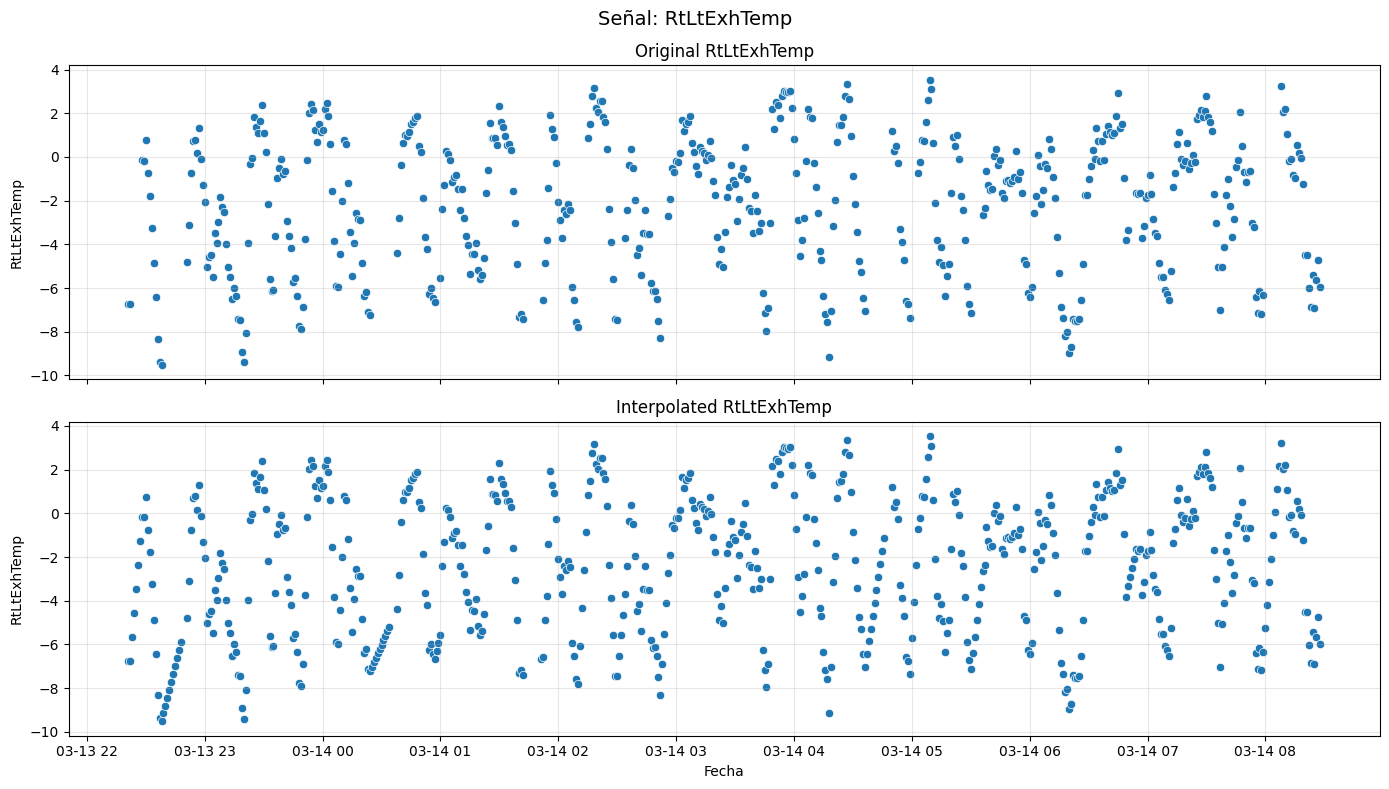

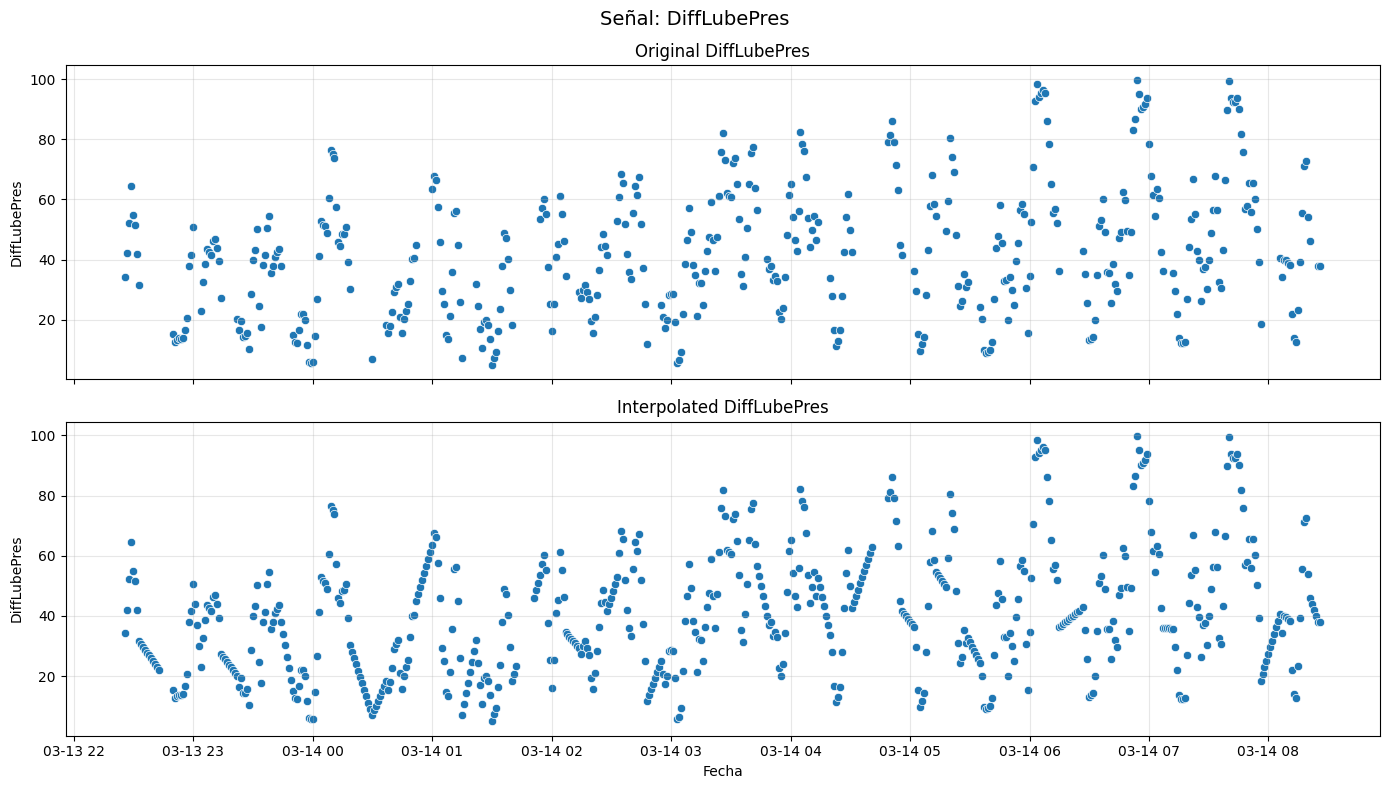

Cycle T_10-484: Imputed values per signal: {'RtLtExhTemp': 82, 'DiffLubePres': 160}


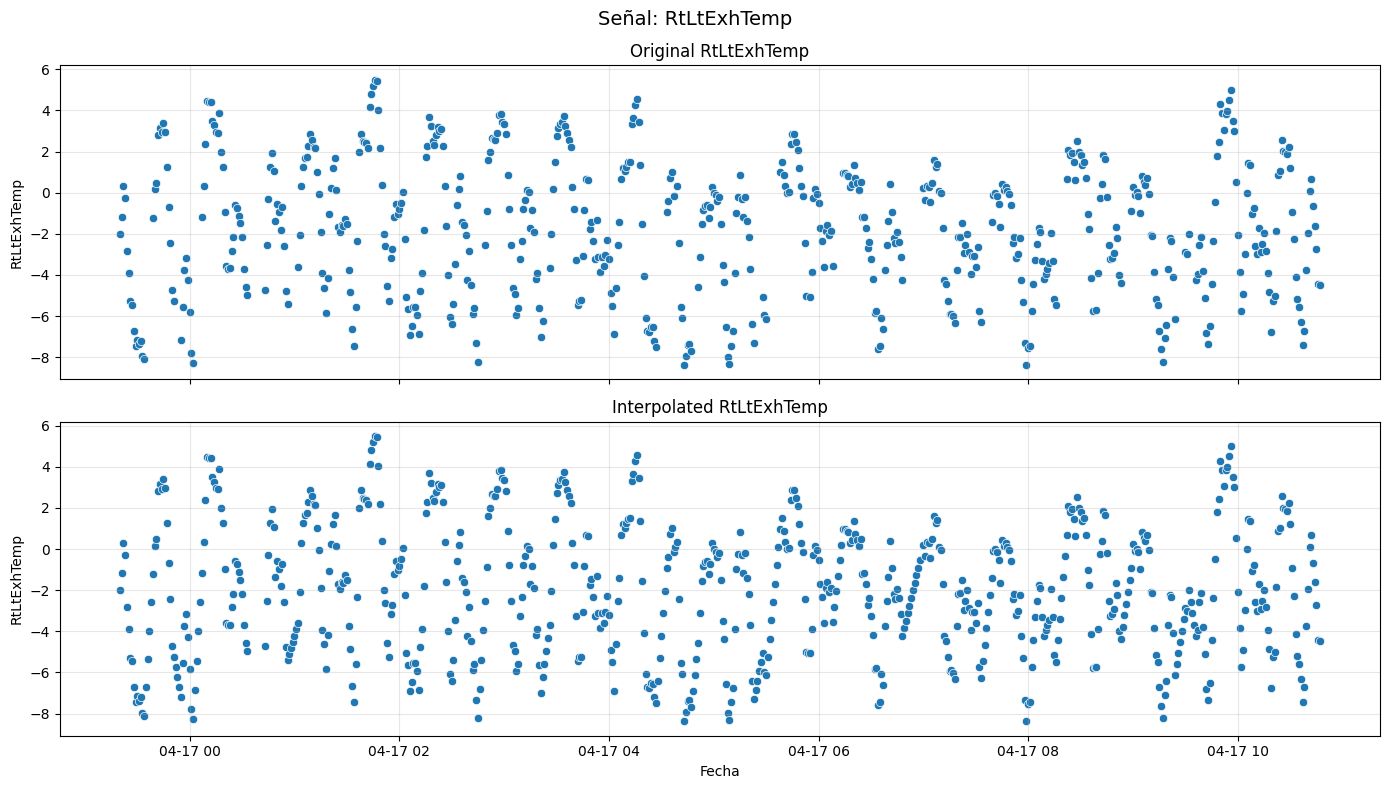

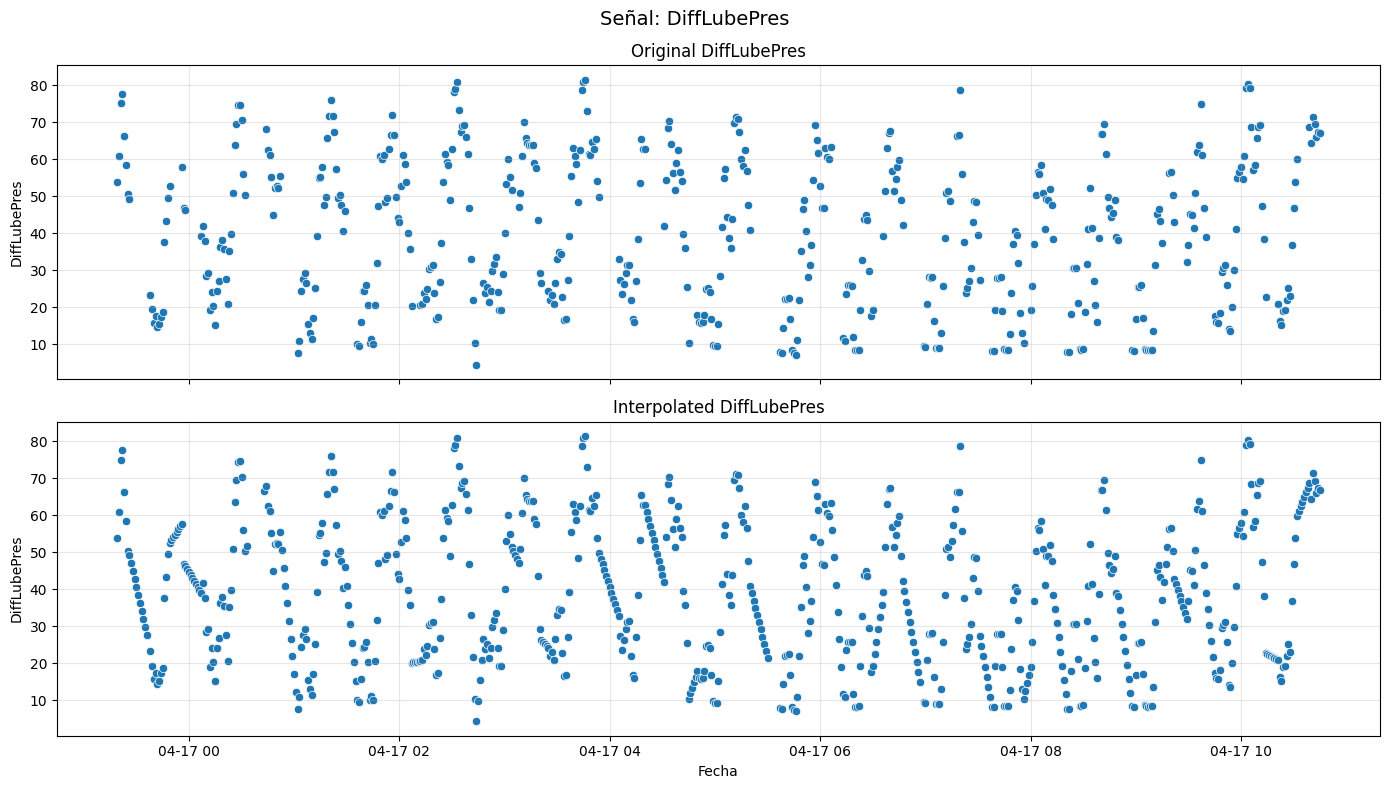

Cycle T_10-1480: Imputed values per signal: {'RtLtExhTemp': 60, 'RtExhTemp': 16, 'DiffLubePres': 81}


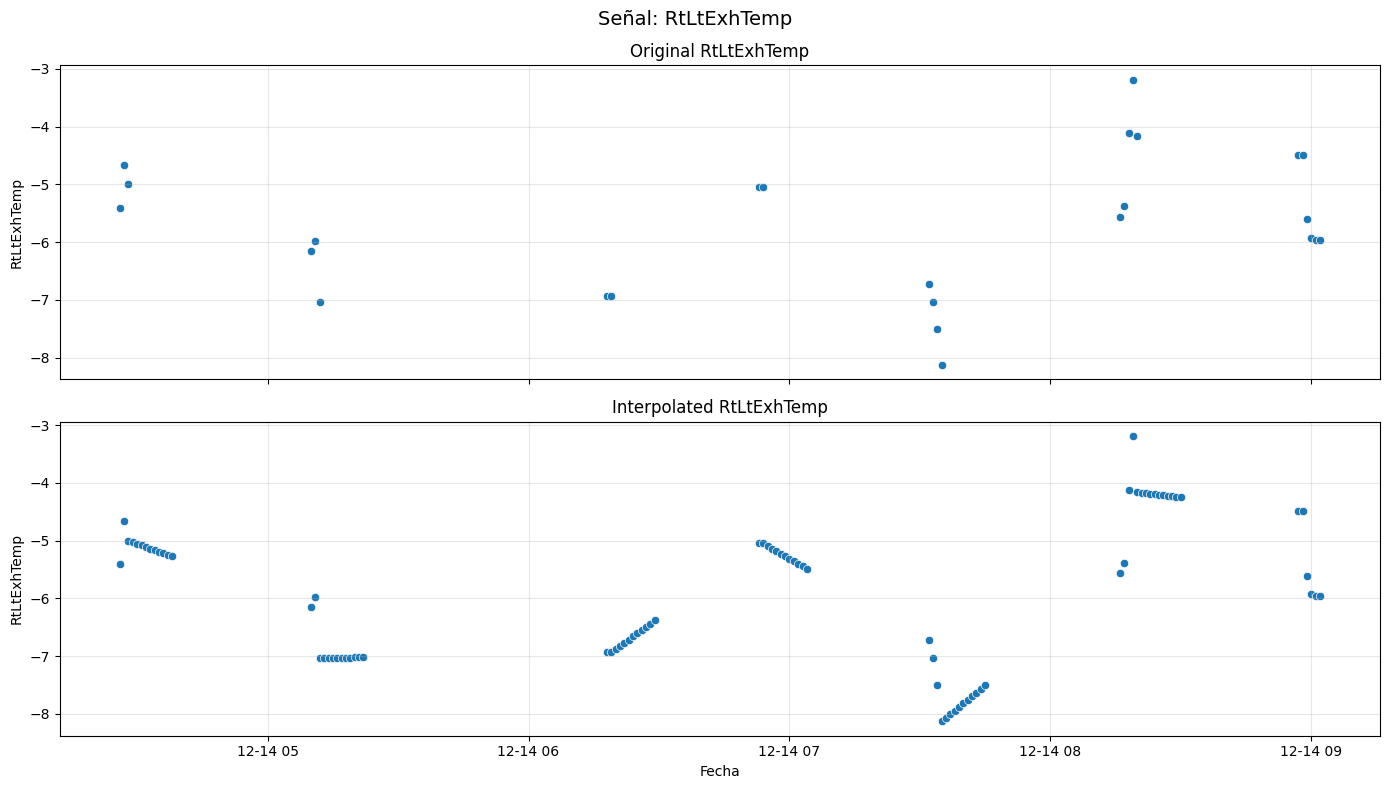

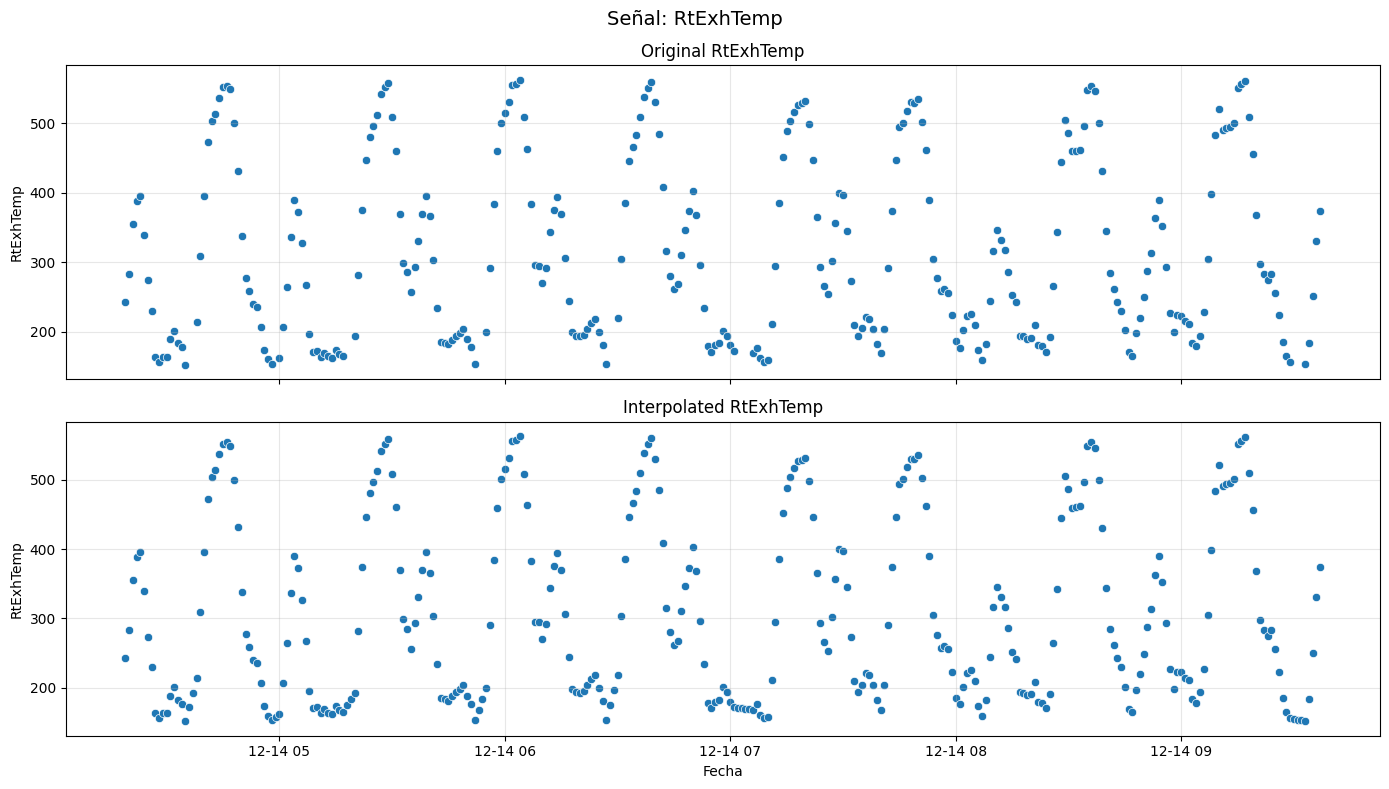

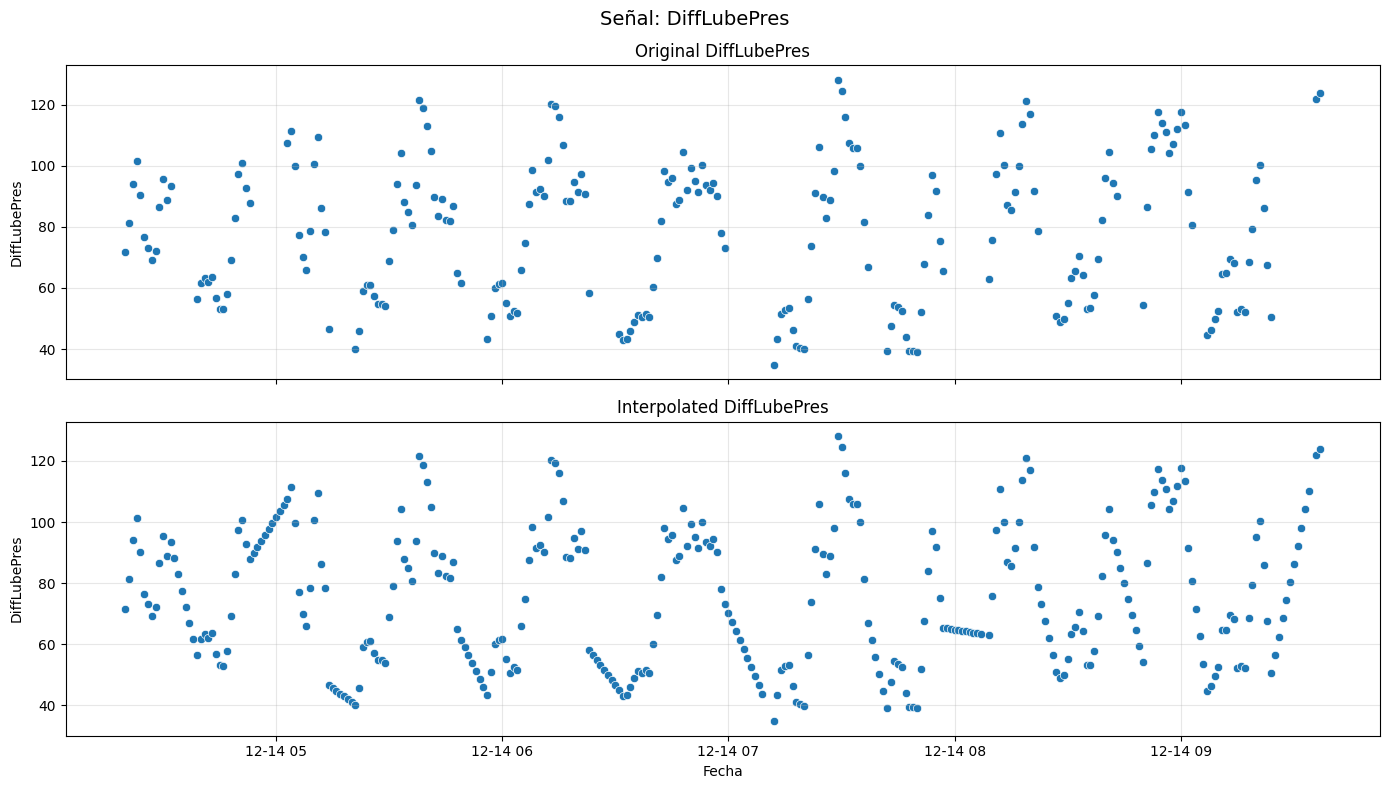

Cycle T_11-970: Imputed values per signal: {'DiffLubePres': 120}


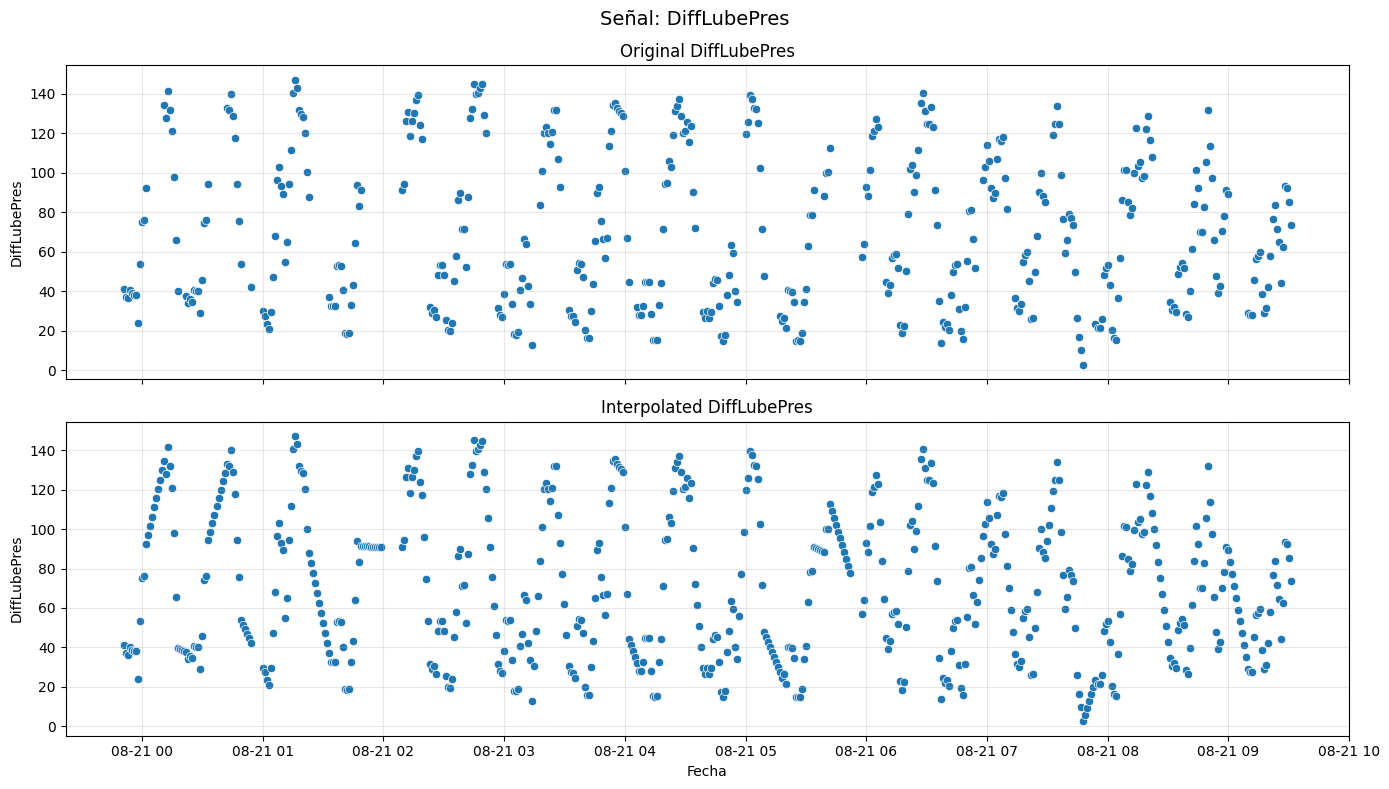

Cycle T_11-1577: Imputed values per signal: {'RtLtExhTemp': 59, 'DiffLubePres': 81}


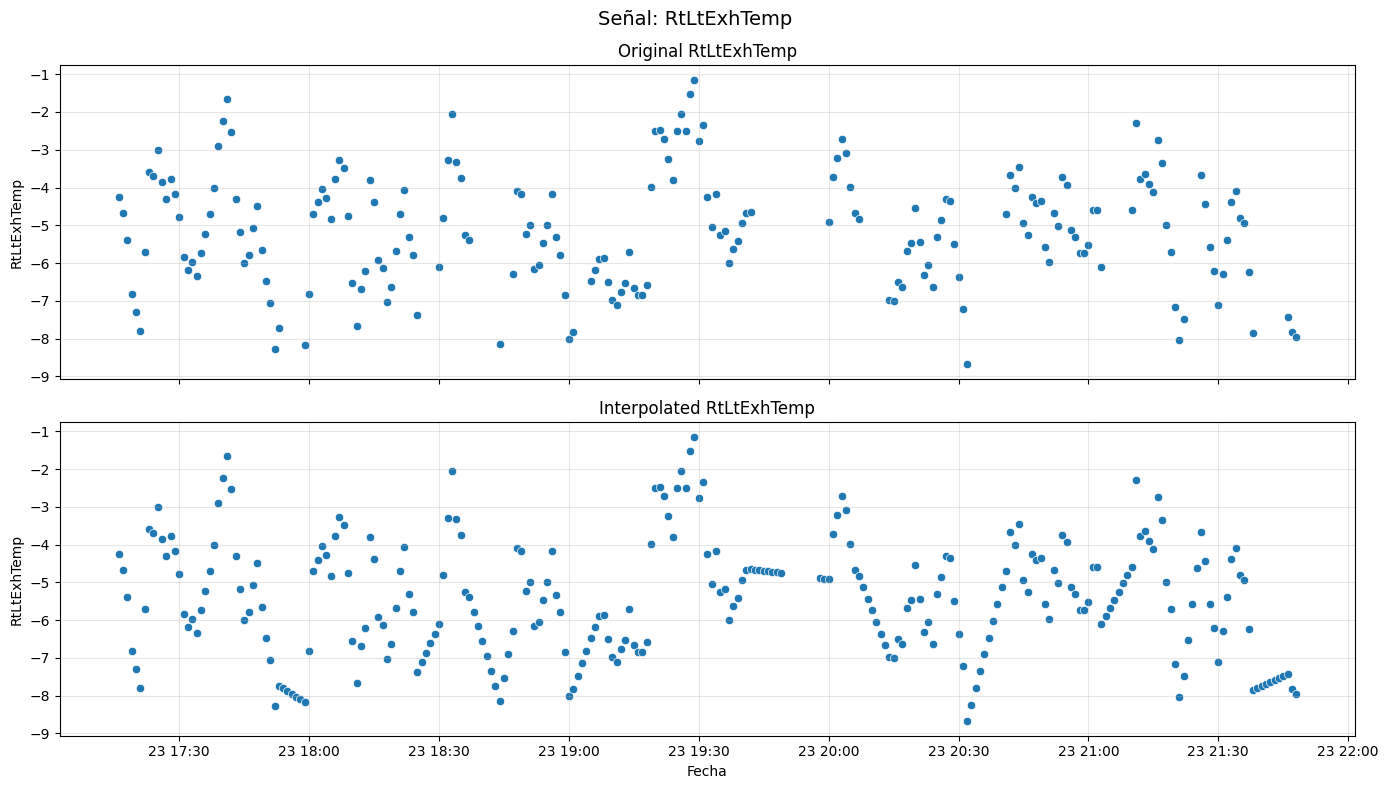

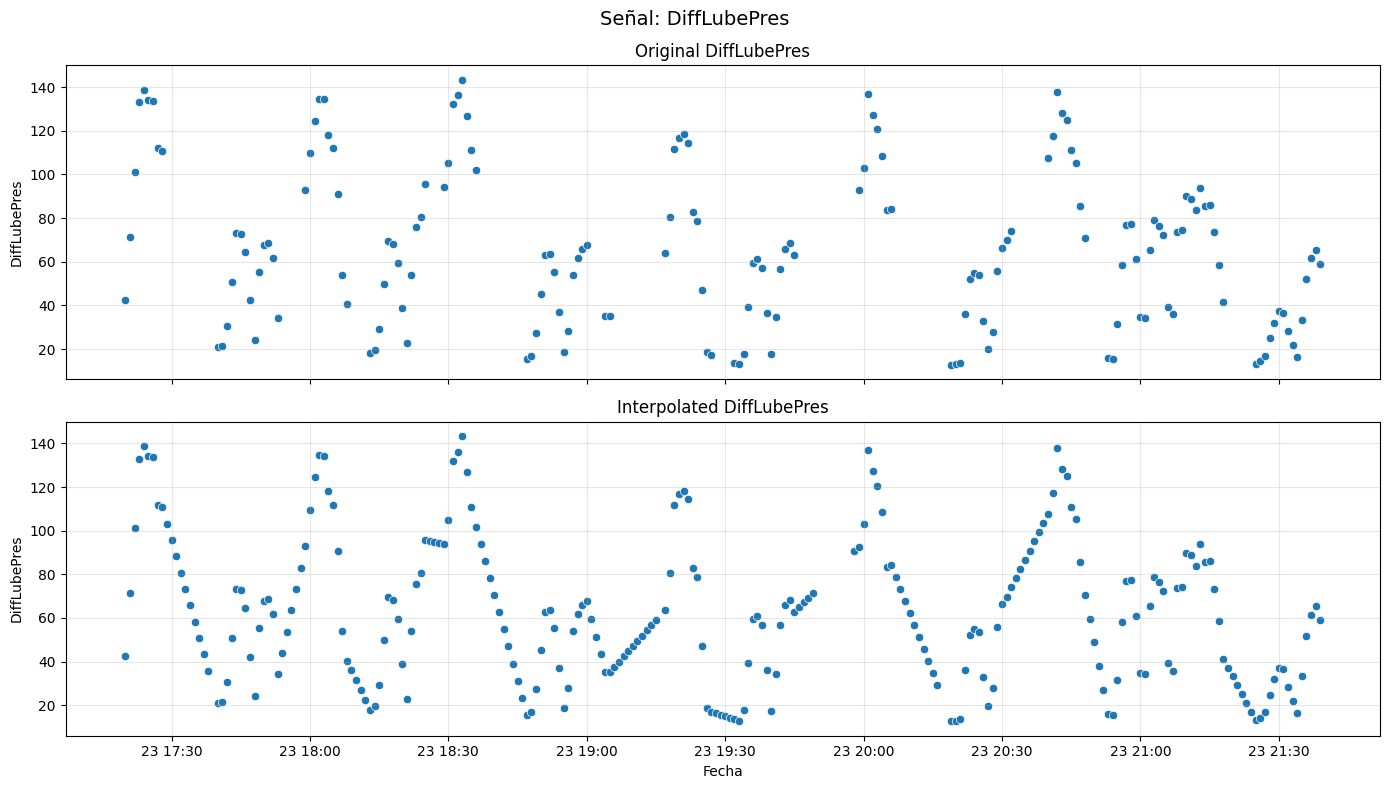

In [ ]:
# =========================
# Config
# =========================
UNIT_COL = "Unit"
TIME_COL = "Fecha"
CAT_COLS = ["EstadoMaquina", "EstadoCarga"]  # se mantienen tal cual

FREQ = "1min"
GAP_THRESHOLD = pd.Timedelta("10min")
MIN_DURATION = pd.Timedelta("4h")
MIN_COVERAGE = 0.75
INTERP_LIMIT = 10

df_final = df_cleaned.copy()

# =========================
# 1) Calcular cycle_id en el DF original
# =========================
dt = df_final.groupby(UNIT_COL)[TIME_COL].diff()
new_cycle = dt.isna() | (dt > GAP_THRESHOLD)
df_final["cycle_id"] = new_cycle.groupby(df_final[UNIT_COL]).cumsum().astype("int64")

# =========================
# 2) Funciones auxiliares
# =========================
freq_td = pd.to_timedelta(FREQ)

def is_valid_cycle(cycle_df: pd.DataFrame) -> bool:
    """Ciclo válido si dura >= 2h y tiene suficiente densidad de muestras."""
    start = cycle_df[TIME_COL].iloc[0]
    end = cycle_df[TIME_COL].iloc[-1]
    duration = end - start

    n = len(cycle_df)
    expected_n = int(round(duration / freq_td)) + 1
    coverage = n / expected_n if expected_n > 0 else 0.0

    return (duration >= MIN_DURATION) and (coverage >= MIN_COVERAGE)

def plot_ts(df_original: pd.DataFrame, df_end: pd.DataFrame, num_cols:list = num_cols, time_col:str = TIME_COL):
    """
    Plotea una señal por figura usando seaborn/matplotlib.
    Arriba: versión original con valores faltantes.
    Abajo: versión interpolada.
    """
    for signal in num_cols:
        fig, axes = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(14, 8),
            sharex=True
        )

        # Arriba: señal original
        sns.scatterplot(
            data=df_original,
            x=time_col,
            y=signal,
            ax=axes[0],
            legend=False
        )
        axes[0].set_title(f"Original {signal}")
        axes[0].set_ylabel(signal)
        axes[0].grid(True, alpha=0.3)

        # Abajo: señal interpolada
        sns.scatterplot(
            data=df_end,
            x=time_col,
            y=signal,
            ax=axes[1],
            legend=False
        )
        axes[1].set_title(f"Interpolated {signal}")
        axes[1].set_xlabel(time_col)
        axes[1].set_ylabel(signal)
        axes[1].grid(True, alpha=0.3)

        fig.suptitle(f"Señal: {signal}", fontsize=14)
        plt.tight_layout()
        plt.show()
    
def interpolate_cycle(cycle_df: pd.DataFrame, num_cols=num_cols, viz:bool = False) -> pd.DataFrame:
    """Interpola SOLO columnas numéricas dentro del ciclo (time-based)."""
    out = cycle_df.copy()

    # columnas numéricas = señales; excluye unit/time/cycle_id y categóricas
    excluded = {UNIT_COL, TIME_COL, "cycle_id", *CAT_COLS}
    candidates = [c for c in out.columns if c not in excluded]

    # si hay alguna señal que venga como object/string por valores raros, la convertimos
    obj_cols = [c for c in candidates if out[c].dtype == "object" or pd.api.types.is_string_dtype(out[c])]
    for c in obj_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    # interpolación
    out = out.set_index(TIME_COL)

    before_na = out[num_cols].isna()
    out[num_cols] = out[num_cols].interpolate(
        method="time",
        limit=INTERP_LIMIT,
        limit_area="inside",
    )
    
    out["imputed_any"] = (before_na & ~out[num_cols].isna()).any(axis=1).astype("int8")
    
    # if the value its true (1% prob) we will plot the timeseries using plot_ts function, to check the interpolation results visually
    if viz:
        n_values_interpolated_per_signal_dict = (before_na & ~out[num_cols].isna()).sum().to_dict()
        max_imputed_values = max(n_values_interpolated_per_signal_dict.values()) if n_values_interpolated_per_signal_dict else 0
        if max_imputed_values/len(cycle_df) > 0.2:  # si se imputó más del 10% de los valores en alguna señal, lo ploteamos para revisar
            random_bool = np.random.choice([False, True], p=[0.996, 0.004])
            if random_bool:
                interpolated_cols = [col for col, n_imputed in n_values_interpolated_per_signal_dict.items() if n_imputed/len(cycle_df) > 0.05]
                relevant_n_values = {col: n for col, n in n_values_interpolated_per_signal_dict.items() if col in interpolated_cols}
                print(f"Cycle {cycle_df[UNIT_COL].iloc[0]}-{cycle_df['cycle_id'].iloc[0]}: Imputed values per signal: {relevant_n_values}")
                plot_ts(cycle_df, out.reset_index(), num_cols=interpolated_cols)

    return out.reset_index()

# =========================
# 3) Split -> filtrar válidos -> interpolar -> concat
# =========================
from tqdm.auto import tqdm

cycles = []
for (_, _), cycle_df in tqdm(df_final.groupby([UNIT_COL, "cycle_id"], sort=False), desc="Processing cycles"):

    if is_valid_cycle(cycle_df):
        cycles.append(interpolate_cycle(cycle_df))

cleaned_cycles_df = pd.concat(cycles, ignore_index=True) if cycles else df_final.head(0).copy()

In [ ]:
cleaned_cycles_df.isna().sum()/len(cleaned_cycles_df)*100

Fecha              0.000000
Unit               0.000000
Estado           100.000000
EstadoMaquina      0.000000
EstadoCarga        0.000000
GPSLat             1.365082
GPSLon             1.365082
GPSElevation       1.344279
CnkcasePres        0.085157
DiffLubePres       5.638755
DiffTemp           0.565953
EngCoolTemp        0.038587
EngOilPres         0.275950
EngSpd             0.000000
GroundSpd          0.005874
LtExhTemp          1.268501
LtFBrkTemp         0.058578
LtRBrkTemp         0.245184
RAftrclrTemp      15.837843
RtExhTemp          1.290601
RtFBrkTemp         7.498587
RtLtExhTemp       12.313029
RtRBrkTemp         0.063511
StrgOilTemp        1.147612
TCOutTemp          0.803381
TrnLubeTemp        1.648334
cycle_id           0.000000
imputed_any        0.000000
dtype: float64

cycle_id
1156    5511
946     5463
776     5022
814     4705
474     4616
864     4573
15      4520
851     4507
30      4431
510     4294
Name: Fecha, dtype: int64

cycle_id
1314    260
1335    260
79      252
1713    250
1699    249
1795    248
1179    247
1531    242
1822    240
658     238
Name: Fecha, dtype: int64

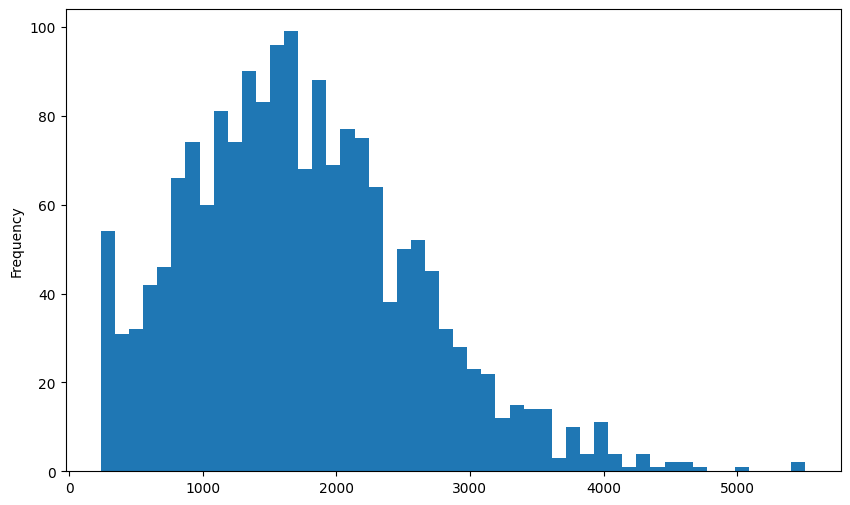

In [ ]:
cycles_rows = cleaned_cycles_df.groupby('cycle_id')['Fecha'].count().sort_values(ascending=False)
cycles_rows.plot(kind='hist', bins=50, figsize=(10,6))

display(cycles_rows.iloc[:10])

display(cycles_rows.iloc[-10:])

In [ ]:
percentile_dict = {col : cleaned_cycles_df[col].quantile([0.05, 0.95]) for col in num_cols if ('GPS' not in col) & ('Spd' not in col)}

out_cols = []
for col in percentile_dict.keys():
    cleaned_cycles_df.loc[:, f'{col}_out_range'] = ~cleaned_cycles_df[col].between(percentile_dict[col][0.05], percentile_dict[col][0.95])
    out_cols.append(f'{col}_out_range') 
    
cycle_summary = cleaned_cycles_df.groupby(['Unit', 'cycle_id'])[out_cols].sum()
cycle_total = cleaned_cycles_df.groupby(['Unit', 'cycle_id']).size().rename('total_rows')
cycle_summary.loc[:, 'total_out_range'] = cycle_summary[out_cols].sum(axis=1)
cycle_summary = cycle_summary.merge(cycle_total, left_index=True, right_index=True)
cycle_summary.loc[:, 'total_ratio'] = cycle_summary['total_out_range'] / cycle_summary['total_rows']
# if ratio < 2.0 => Normal, else Anomalous
cycle_summary.loc[:, 'Label'] = np.where(cycle_summary['total_ratio'] < 2, 'Normal', 'Anomalous')

In [ ]:
cleaned_cycles_df = cleaned_cycles_df.merge(cycle_summary['Label'], left_on=['Unit', 'cycle_id'], right_index=True)

del cycles, cycle_summary, cycle_total
del percentile_dict, out_cols
del df, df_cleaned, df_final

cleaned_cycles_df

,Fecha,Unit,Estado,EstadoMaquina,EstadoCarga,GPSLat,GPSLon,GPSElevation,CnkcasePres,DiffLubePres,...,DiffLubePres_out_range,DiffTemp_out_range,TrnLubeTemp_out_range,TCOutTemp_out_range,RtRBrkTemp_out_range,RtFBrkTemp_out_range,LtRBrkTemp_out_range,LtFBrkTemp_out_range,StrgOilTemp_out_range,Label
0,2025-01-01 10:05:00,T_10,NaN,ND,Sin Carga,-30.254391,-71.088554,984.782691,-0.336347,NaN,...,True,False,True,True,True,True,True,True,True,Normal
1,2025-01-01 10:06:00,T_10,NaN,ND,Sin Carga,-30.254361,-71.088596,989.330357,-0.322655,NaN,...,True,False,False,False,True,True,False,True,False,Normal
2,2025-01-01 10:07:00,T_10,NaN,ND,Sin Carga,-30.254359,-71.088587,995.527269,-0.307973,NaN,...,True,False,False,False,True,False,False,False,False,Normal
3,2025-01-01 10:08:00,T_10,NaN,ND,Sin Carga,-30.254393,-71.088536,984.842000,-0.292973,NaN,...,True,True,False,False,True,False,False,False,False,Normal
4,2025-01-01 10:09:00,T_10,NaN,ND,Sin Carga,-30.254457,-71.088697,998.712070,-0.242314,NaN,...,True,True,False,False,True,False,False,False,False,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3081349,2026-01-30 23:56:00,T_9,NaN,Operacional Alto,Sin Carga,-30.254518,-71.096484,1023.049999,0.107313,131.404679,...,False,False,False,False,False,False,False,False,False,Normal
3081350,2026-01-30 23:57:00,T_9,NaN,Operacional Alto,Sin Carga,-30.250783,-71.099808,1050.487712,0.091365,143.147552,...,False,False,False,False,False,False,False,False,False,Normal
3081351,2026-01-30 23:58:00,T_9,NaN,Ralenti Alto,Sin Carga,-30.246659,-71.101252,1052.864915,0.069494,139.727043,...,False,False,False,False,False,False,False,False,False,Normal
3081352,2026-01-30 23:59:00,T_9,NaN,Ralenti Alto,Sin Carga,-30.247095,-71.100186,1004.574576,0.073976,141.599384,...,False,False,False,False,False,False,False,False,False,Normal


## Model

In [ ]:
from sklearn.preprocessing import RobustScaler
import json

component_mapping = json.load(open('../data/telemetry/component_signals_mapping.json', 'r'))
def build_lstm_autoencoder(n_signals: int, sequence_length: int):
    """
    Build LSTM autoencoder for multivariate telemetry.
    
    Args:
        n_signals: Number of input signals (features)
        sequence_length: Time steps in sequence (e.g., 168 hours for 1 week)
    """
    # Encoder
    encoder_inputs = layers.Input(shape=(sequence_length, n_signals))
    x = layers.LSTM(128, return_sequences=True)(encoder_inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64, return_sequences=False)(x)
    encoder = Model(encoder_inputs, x, name='encoder')
    
    # Decoder
    decoder_input = layers.Input(shape=(64,))
    x = layers.RepeatVector(sequence_length)(decoder_input)
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(128, return_sequences=True)(x)
    decoder_output = layers.TimeDistributed(layers.Dense(n_signals))(x)
    decoder = Model(decoder_input, decoder_output, name='decoder')
    
    # Full autoencoder
    autoencoder_input = layers.Input(shape=(sequence_length, n_signals))
    encoded = encoder(autoencoder_input)
    decoded = decoder(encoded)
    autoencoder = Model(autoencoder_input, decoded, name='autoencoder')
    
    # Compile model
    autoencoder.compile(optimizer='adam', loss='mse')
    
    return autoencoder, encoder, decoder


WINDOW_SIZE = 4 * 60 # 4 hours of data at 1-minute frequency = 240 time steps
def train_lstm_autoencoder(
    training_df: pd.DataFrame,
    component_mapping: dict,
    client: str,
    component: str
):
    """
    Train LSTM autoencoder on historical normal data for a component.
    """
    signal_cols = component_mapping['components'][component]['signals']
    signal_cols = [col for col in signal_cols if col in training_df.columns]
    
    # Filter to Normal operation only (for training)
    normal_data = training_df[training_df['Label'] == 'Normal']  # Requires labeled historical data
    
    # Prepare sequences (sliding window)
    sequences = []
    for cycle in normal_data['cycle_id'].unique():
        cycle_data = normal_data[normal_data['cycle_id'] == cycle][signal_cols].values
        
        if cycle_data.shape[0] < WINDOW_SIZE*2:  # Solo crear secuencias si el ciclo tiene suficientes datos para al menos una ventana
            continue
        
        # Normalize
        scaler = RobustScaler()
        cycle_data_norm = scaler.fit_transform(cycle_data)
        
        # Create sliding windows - per cycle -- Note : Each unit has very cycle, so we will create the windows for each unit separately to avoid mixing different units in the same sequence
        for i in range(len(cycle_data_norm) - WINDOW_SIZE):
            sequences.append(cycle_data_norm[i:i+WINDOW_SIZE])    
            
    X_train = np.array(sequences)
    
    # Build and train model
    model, encoder, decoder = build_lstm_autoencoder(
        n_signals=len(signal_cols),
        sequence_length=WINDOW_SIZE
    )
    
    model.fit(
        X_train, X_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
        ]
    )
    
    # Save model
    model_path = f"models/autoencoders/{client}/{component}_lstm_ae.h5"
    model.save(model_path)
    
    return model

model = train_lstm_autoencoder(cleaned_cycles_df, component_mapping, 'cda', 'Tren de fuerza')

c:\Users\patri\Coddi\Proyectos\telemetry_dashboard\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
c:\Users\patri\Coddi\Proyectos\telemetry_dashboard\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\patri\Coddi\Proyectos\telemetry_dashboard\.venv\Lib\site-packages\sklearn\preprocessing\_data.py:1705: RuntimeWarning: All-NaN slice encountered
  self.center_ = np.nanmedian(X, axis=0)
c:\Users\patri\Coddi\Proyectos\telemetry_dashboard\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


Epoch 1/50
11636/34251 ━━━━━━━━━━━━━━━━━━━━ 1:59:03 316ms/step - loss: nan